### step3_A: Direct vs Self-plan 정량 비교

self-plan 구현단계에서 step3_A 점검

In [1]:
# ps -ef | grep jupyter
# 실행중인 jupyter notebook 프로세스 확인

### 1. 두 결과 파일 로드

In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt


DIRECT_PATH = Path("../direct_stdin/results.jsonl")
SELF_PLAN_PATH = Path("../self_plan_stdin/results.jsonl")


def load_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Result file not found: {path.resolve()}"
        )

    records = []

    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            if not line.strip():
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON at line {line_number}: {path}"
                ) from error

    return pd.DataFrame(records)


direct_df = load_jsonl(DIRECT_PATH)
self_plan_df = load_jsonl(SELF_PLAN_PATH)

print(f"Direct records    : {len(direct_df)}")
print(f"Self-Plan records : {len(self_plan_df)}")

Direct records    : 10
Self-Plan records : 10


### 2. 동일한 문제를 사용했는지 확인

전략 비교에서는 반드시 problem ID 집합이 같아야함.

In [3]:
direct_ids = set(direct_df["problem_id"])
self_plan_ids = set(self_plan_df["problem_id"])

print("Direct only:")
print(sorted(direct_ids - self_plan_ids))

print("\nSelf-Plan only:")
print(sorted(self_plan_ids - direct_ids))

assert direct_ids == self_plan_ids, (
    "Direct와 Self-Plan의 problem_id 집합이 다릅니다."
)

print("\n[PASS] Same problem set")

Direct only:
[]

Self-Plan only:
[]

[PASS] Same problem set


In [4]:
assert (
    direct_df["problem_id"].tolist()
    == self_plan_df["problem_id"].tolist()
), "Problem order is different."

print("[PASS] Same problem order")

[PASS] Same problem order


### 3.파생 지표 생성

In [5]:
def add_metrics(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    result["test_pass_ratio"] = result.apply(
        lambda row: (
            row["passed_tests"] / row["total_tests"]
            if row["total_tests"] > 0
            else 0.0
        ),
        axis=1,
    )

    result["total_tokens"] = (
        result["prompt_tokens"]
        + result["completion_tokens"]
    )

    result["total_runtime"] = (
        result["generation_time"]
        + result["execution_time"]
    )

    return result


direct_df = add_metrics(direct_df)
self_plan_df = add_metrics(self_plan_df)

### 4. 전략별 전체 요약

In [6]:
def summarize_strategy(
    df: pd.DataFrame,
    strategy_name: str,
) -> dict:
    return {
        "strategy": strategy_name,
        "num_problems": len(df),
        "num_passed": int(df["passed"].sum()),
        "pass_rate": float(df["passed"].mean()),
        "mean_test_pass_ratio": float(
            df["test_pass_ratio"].mean()
        ),
        "mean_prompt_tokens": float(
            df["prompt_tokens"].mean()
        ),
        "mean_completion_tokens": float(
            df["completion_tokens"].mean()
        ),
        "mean_total_tokens": float(
            df["total_tokens"].mean()
        ),
        "mean_generation_time": float(
            df["generation_time"].mean()
        ),
        "mean_execution_time": float(
            df["execution_time"].mean()
        ),
        "mean_total_runtime": float(
            df["total_runtime"].mean()
        ),
    }


summary_df = pd.DataFrame(
    [
        summarize_strategy(direct_df, "Direct"),
        summarize_strategy(
            self_plan_df,
            "Self-Plan",
        ),
    ]
)

display(summary_df)

,strategy,num_problems,num_passed,pass_rate,mean_test_pass_ratio,mean_prompt_tokens,mean_completion_tokens,mean_total_tokens,mean_generation_time,mean_execution_time,mean_total_runtime
0,Direct,10,1,0.1,0.508205,609.1,240.3,849.4,2.215089,0.751569,2.966658
1,Self-Plan,10,0,0.0,0.362051,1517.3,432.4,1949.7,3.996458,0.100576,4.097034


### 5. Self-Plan의 상대 비용 증가율

Self-Plan이 Direct보다
- 몇 배 많은 토큰을 사용했는가
- 몇 배 오래 걸렸는가

In [7]:
direct_summary = summary_df.loc[
    summary_df["strategy"] == "Direct"
].iloc[0]

self_summary = summary_df.loc[
    summary_df["strategy"] == "Self-Plan"
].iloc[0]


cost_comparison = pd.Series(
    {
        "prompt_token_multiplier": (
            self_summary["mean_prompt_tokens"]
            / direct_summary["mean_prompt_tokens"]
        ),
        "completion_token_multiplier": (
            self_summary["mean_completion_tokens"]
            / direct_summary["mean_completion_tokens"]
        ),
        "total_token_multiplier": (
            self_summary["mean_total_tokens"]
            / direct_summary["mean_total_tokens"]
        ),
        "generation_time_multiplier": (
            self_summary["mean_generation_time"]
            / direct_summary["mean_generation_time"]
        ),
        "total_runtime_multiplier": (
            self_summary["mean_total_runtime"]
            / direct_summary["mean_total_runtime"]
        ),
    }
)

display(cost_comparison.to_frame("Self-Plan / Direct"))

,Self-Plan / Direct
prompt_token_multiplier,2.491052
completion_token_multiplier,1.799417
total_token_multiplier,2.295385
generation_time_multiplier,1.804197
total_runtime_multiplier,1.381027


### 6. Self-Plan 단계별 비용 분리

Self-Plan은 strategy_trace에 두 단계가 있음. 분리해서 해석

In [8]:
self_plan_cost_rows = []

for _, row in self_plan_df.iterrows():
    trace = row["strategy_trace"]

    plan_step = next(
        step
        for step in trace
        if step["name"] == "plan_generation"
    )

    code_step = next(
        step
        for step in trace
        if step["name"] == "code_generation"
    )

    self_plan_cost_rows.append(
        {
            "problem_id": row["problem_id"],
            "difficulty": row["difficulty"],
            "passed": row["passed"],

            "plan_prompt_tokens": (
                plan_step["prompt_tokens"]
            ),
            "plan_completion_tokens": (
                plan_step["completion_tokens"]
            ),
            "plan_generation_time": (
                plan_step["generation_time"]
            ),

            "code_prompt_tokens": (
                code_step["prompt_tokens"]
            ),
            "code_completion_tokens": (
                code_step["completion_tokens"]
            ),
            "code_generation_time": (
                code_step["generation_time"]
            ),
        }
    )

self_plan_cost_df = pd.DataFrame(
    self_plan_cost_rows
)

display(self_plan_cost_df)

,problem_id,difficulty,passed,plan_prompt_tokens,plan_completion_tokens,plan_generation_time,code_prompt_tokens,code_completion_tokens,code_generation_time
0,1873_A,easy,False,554,271,2.660939,785,183,1.701918
1,1873_B,easy,False,449,245,2.232912,655,165,1.517066
2,1873_D,easy,False,665,215,1.974289,841,276,2.566413
3,1883_B,medium,False,849,170,1.580023,979,181,1.675370
4,1883_C,medium,False,851,210,1.937343,1022,254,2.335661
5,1899_A,easy,False,393,269,2.450480,623,120,1.109430
6,1899_B,hard,False,974,142,1.323629,1077,214,1.974856
7,1899_C,hard,False,610,228,2.092788,799,344,3.142385
8,1899_D,hard,False,864,225,2.067319,1050,172,1.594332
9,abc301_a,easy,False,462,248,2.264467,671,192,1.762957


In [9]:
# 단계별 평균
self_plan_stage_summary = pd.Series(
    {
        "mean_plan_prompt_tokens": (
            self_plan_cost_df[
                "plan_prompt_tokens"
            ].mean()
        ),
        "mean_plan_completion_tokens": (
            self_plan_cost_df[
                "plan_completion_tokens"
            ].mean()
        ),
        "mean_plan_generation_time": (
            self_plan_cost_df[
                "plan_generation_time"
            ].mean()
        ),
        "mean_code_prompt_tokens": (
            self_plan_cost_df[
                "code_prompt_tokens"
            ].mean()
        ),
        "mean_code_completion_tokens": (
            self_plan_cost_df[
                "code_completion_tokens"
            ].mean()
        ),
        "mean_code_generation_time": (
            self_plan_cost_df[
                "code_generation_time"
            ].mean()
        ),
    }
)

display(
    self_plan_stage_summary.to_frame("value")
)

,value
mean_plan_prompt_tokens,667.100000
mean_plan_completion_tokens,222.300000
mean_plan_generation_time,2.058419
mean_code_prompt_tokens,850.200000
mean_code_completion_tokens,210.100000
mean_code_generation_time,1.938039


### 7. 난이도별 비교

In [10]:
def summarize_by_difficulty(
    df: pd.DataFrame,
    strategy_name: str,
) -> pd.DataFrame:
    summary = (
        df.groupby("difficulty")
        .agg(
            problems=("problem_id", "count"),
            passed=("passed", "sum"),
            pass_rate=("passed", "mean"),
            mean_test_pass_ratio=(
                "test_pass_ratio",
                "mean",
            ),
            mean_total_tokens=(
                "total_tokens",
                "mean",
            ),
            mean_generation_time=(
                "generation_time",
                "mean",
            ),
        )
        .reset_index()
    )

    summary["strategy"] = strategy_name
    return summary


difficulty_df = pd.concat(
    [
        summarize_by_difficulty(
            direct_df,
            "Direct",
        ),
        summarize_by_difficulty(
            self_plan_df,
            "Self-Plan",
        ),
    ],
    ignore_index=True,
)

display(difficulty_df)

,difficulty,problems,passed,pass_rate,mean_test_pass_ratio,mean_total_tokens,mean_generation_time,strategy
0,easy,5,1,0.2,0.677949,684.000000,2.201142,Direct
1,hard,3,0,0.0,0.564103,1002.666667,2.242656,Direct
2,medium,2,0,0.0,0.000000,1033.000000,2.208605,Direct
3,easy,5,0,0.0,0.324103,1656.400000,4.048174,Self-Plan
4,hard,3,0,0.0,0.461538,2233.000000,4.065103,Self-Plan
5,medium,2,0,0.0,0.307692,2258.000000,3.764198,Self-Plan


### 8. 문제별 성능 변화

Direct와 Self-Plan을 problem ID 기준으로 합치기

In [11]:
comparison_df = direct_df[
    [
        "problem_id",
        "title",
        "difficulty",
        "passed",
        "status",
        "passed_tests",
        "total_tests",
        "test_pass_ratio",
        "total_tokens",
        "generation_time",
    ]
].merge(
    self_plan_df[
        [
            "problem_id",
            "passed",
            "status",
            "passed_tests",
            "total_tests",
            "test_pass_ratio",
            "total_tokens",
            "generation_time",
        ]
    ],
    on="problem_id",
    suffixes=("_direct", "_self_plan"),
)

comparison_df["pass_change"] = (
    comparison_df["passed_self_plan"].astype(int)
    - comparison_df["passed_direct"].astype(int)
)

comparison_df["test_pass_ratio_change"] = (
    comparison_df["test_pass_ratio_self_plan"]
    - comparison_df["test_pass_ratio_direct"]
)

comparison_df["token_increase"] = (
    comparison_df["total_tokens_self_plan"]
    - comparison_df["total_tokens_direct"]
)

comparison_df["generation_time_increase"] = (
    comparison_df["generation_time_self_plan"]
    - comparison_df["generation_time_direct"]
)

display(comparison_df)

,problem_id,title,difficulty,passed_direct,status_direct,passed_tests_direct,total_tests_direct,test_pass_ratio_direct,total_tokens_direct,generation_time_direct,...,status_self_plan,passed_tests_self_plan,total_tests_self_plan,test_pass_ratio_self_plan,total_tokens_self_plan,generation_time_self_plan,pass_change,test_pass_ratio_change,token_increase,generation_time_increase
0,1873_A,A. Short Sort,easy,False,WRONG_ANSWER,3,5,0.600000,634,1.459637,...,WRONG_ANSWER,3,5,0.600000,1793,4.362856,0,0.000000,1159,2.903219
1,1873_B,B. Good Kid,easy,False,WRONG_ANSWER,12,13,0.923077,646,2.316546,...,WRONG_ANSWER,0,13,0.000000,1514,3.749978,0,-0.923077,868,1.433432
2,1873_D,D. 1D Eraser,easy,False,WRONG_ANSWER,0,13,0.000000,1233,5.689609,...,WRONG_ANSWER,0,13,0.000000,1997,4.540702,0,0.000000,764,-1.148907
3,1883_B,B. Chemistry,medium,False,RUNTIME_ERROR,0,4,0.000000,1014,2.044510,...,WRONG_ANSWER,0,4,0.000000,2179,3.255393,0,0.000000,1165,1.210883
4,1883_C,C. Raspberries,medium,False,RUNTIME_ERROR,0,13,0.000000,1052,2.372700,...,WRONG_ANSWER,8,13,0.615385,2337,4.273004,0,0.615385,1285,1.900304
5,1899_A,A. Game with Integers,easy,True,PASS,13,13,1.000000,411,0.696208,...,WRONG_ANSWER,2,13,0.153846,1405,3.559910,-1,-0.846154,994,2.863702
6,1899_B,B. 250 Thousand Tons of TNT,hard,False,WRONG_ANSWER,2,13,0.153846,1260,3.148414,...,RUNTIME_ERROR,0,13,0.000000,2407,3.298485,0,-0.153846,1147,0.150072
7,1899_C,C. Yarik and Array,hard,False,WRONG_ANSWER,8,13,0.615385,763,1.933557,...,WRONG_ANSWER,6,13,0.461538,1981,5.235173,0,-0.153846,1218,3.301616
8,1899_D,D. Yarik and Musical Notes,hard,False,WRONG_ANSWER,12,13,0.923077,985,1.645998,...,WRONG_ANSWER,12,13,0.923077,2311,3.661650,0,0.000000,1326,2.015652
9,abc301_a,Overall Winner,easy,False,WRONG_ANSWER,13,15,0.866667,496,0.843709,...,WRONG_ANSWER,13,15,0.866667,1573,4.027424,0,0.000000,1077,3.183715


In [12]:
def classify_change(row: pd.Series) -> str:
    if (
        not row["passed_direct"]
        and row["passed_self_plan"]
    ):
        return "IMPROVED_TO_PASS"

    if (
        row["passed_direct"]
        and not row["passed_self_plan"]
    ):
        return "DEGRADED_FROM_PASS"

    if (
        row["test_pass_ratio_self_plan"]
        > row["test_pass_ratio_direct"]
    ):
        return "PARTIALLY_IMPROVED"

    if (
        row["test_pass_ratio_self_plan"]
        < row["test_pass_ratio_direct"]
    ):
        return "DEGRADED"

    return "UNCHANGED"


comparison_df["change_category"] = (
    comparison_df.apply(
        classify_change,
        axis=1,
    )
)

display(
    comparison_df[
        [
            "problem_id",
            "difficulty",
            "passed_direct",
            "passed_self_plan",
            "test_pass_ratio_direct",
            "test_pass_ratio_self_plan",
            "change_category",
        ]
    ]
)

print(
    comparison_df[
        "change_category"
    ].value_counts()
)

,problem_id,difficulty,passed_direct,passed_self_plan,test_pass_ratio_direct,test_pass_ratio_self_plan,change_category
0,1873_A,easy,False,False,0.600000,0.600000,UNCHANGED
1,1873_B,easy,False,False,0.923077,0.000000,DEGRADED
2,1873_D,easy,False,False,0.000000,0.000000,UNCHANGED
3,1883_B,medium,False,False,0.000000,0.000000,UNCHANGED
4,1883_C,medium,False,False,0.000000,0.615385,PARTIALLY_IMPROVED
5,1899_A,easy,True,False,1.000000,0.153846,DEGRADED_FROM_PASS
6,1899_B,hard,False,False,0.153846,0.000000,DEGRADED
7,1899_C,hard,False,False,0.615385,0.461538,DEGRADED
8,1899_D,hard,False,False,0.923077,0.923077,UNCHANGED
9,abc301_a,easy,False,False,0.866667,0.866667,UNCHANGED


change_category
UNCHANGED             5
DEGRADED              3
PARTIALLY_IMPROVED    1
DEGRADED_FROM_PASS    1
Name: count, dtype: int64


---

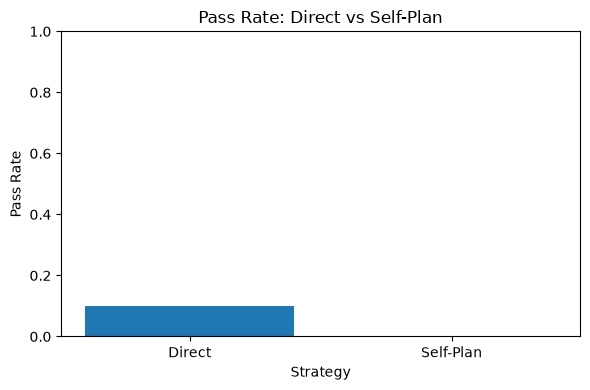

In [13]:
# 전략별 Pass Rate 그래프
plt.figure(figsize=(6, 4))

plt.bar(
    summary_df["strategy"],
    summary_df["pass_rate"],
)

plt.title("Pass Rate: Direct vs Self-Plan")
plt.xlabel("Strategy")
plt.ylabel("Pass Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

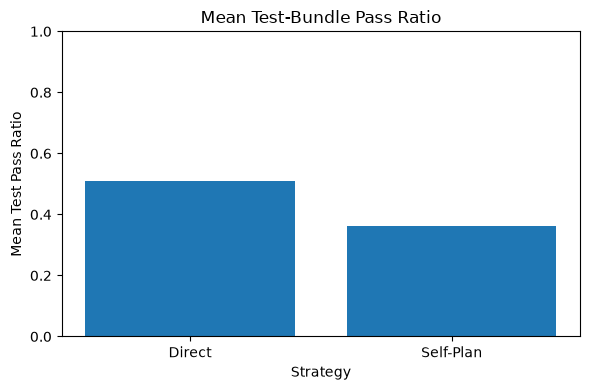

In [14]:
# 평균 test pass ratio 그래프
plt.figure(figsize=(6, 4))

plt.bar(
    summary_df["strategy"],
    summary_df["mean_test_pass_ratio"],
)

plt.title(
    "Mean Test-Bundle Pass Ratio"
)
plt.xlabel("Strategy")
plt.ylabel("Mean Test Pass Ratio")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

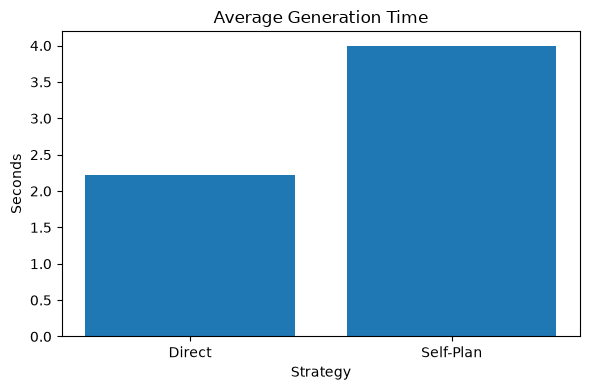

In [15]:
# 평균 생성 시간 비교
plt.figure(figsize=(6, 4))

plt.bar(
    summary_df["strategy"],
    summary_df["mean_generation_time"],
)

plt.title("Average Generation Time")
plt.xlabel("Strategy")
plt.ylabel("Seconds")
plt.tight_layout()
plt.show()